# Домашнє завдання: ETL-пайплайни для аналітиків даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.

### Завдання 1: Створення таблиці курсів валют та API інтеграція (2 бали)

**Повторіть процедуру з лекції:** створіть таблицю для курсів валют, але вже в цій базі даних. Результатом має бути нова таблиця з курсами валют USD, EUR, UAH в БД (можна завантажити більше валют). Продемонструйте, що таблиця була додана, використовуючи SELECT.

Тобто тут ви можете прямо скопіювати код з лекції, внести необхідні зміни і запустити. Головне - отримати таблицю в БД classicmodels.

In [ ]:
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import requests
import datetime
import json

In [ ]:
# Підключення до БД
def create_connection():
    load_dotenv()

    host = os.getenv('DB_HOST')
    port = os.getenv('DB_PORT', '3306')
    user = os.getenv('DB_USER')
    password = os.getenv('DB_PASSWORD')
    database = os.getenv('DB_NAME')

    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    engine = create_engine(
        connection_string,
        pool_size=1,
        max_overflow=20,
        pool_pre_ping=True,
        echo=False
    )

    return engine


# Використовуємо підключення з попередніх завдань
engine = create_connection()

In [ ]:
def create_currency_table(engine):
    """Створює таблицю для курсів валют"""

    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.connect() as conn:
        conn.execute(create_table_sql)
        conn.commit()

    print("✅ Таблиця currency_rates створена")

def fetch_exchange_rates():
    """Отримує курси валют з API"""
    try:
        # Безкоштовний API курсів валют
        url = "https://api.exchangerate-api.com/v4/latest/USD"
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        # Валюти що нас цікавлять для ClassicModels (міжнародна компанія)
        currencies = ['EUR', 'GBP', 'JPY', 'CAD', 'AUD', 'CHF', 'SEK', 'NOK', 'DKK']
        rates = {}

        for currency in currencies:
            if currency in data['rates']:
                rates[currency] = data['rates'][currency]

        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None

def save_exchange_rates(engine, rates_dict, rate_date):
    """Зберігає курси в БД з обробкою конфліктів"""

    if not rates_dict:
        print("❌ Немає даних для збереження")
        return False

    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.connect() as conn:
            with conn.begin():
                for currency, rate in rates_dict.items():
                    conn.execute(insert_sql, {
                        'currency': currency,
                        'rate': rate,
                        'date': rate_date
                    })

        print(f"✅ Збережено {len(rates_dict)} курсів валют на {rate_date}")
        return True

    except Exception as e:
        print(f"❌ Помилка збереження: {e}")
        return False

# Виконуємо завантаження курсів
print("🔧 Створення таблиці курсів валют...")
create_currency_table(engine)

print("📡 Отримання курсів валют з API...")
rates, date = fetch_exchange_rates()

if rates:
    print(f"Отримані курси на {date}:")
    for currency, rate in rates.items():
        print(f"  1 USD = {rate:.4f} {currency}")

    # Зберігаємо в БД
    if save_exchange_rates(engine, rates, date):
        # Перевіряємо збережені дані
        verification_df = pd.read_sql(
            "SELECT * FROM currency_rates ORDER BY created_at DESC LIMIT 10",
            engine
        )
        print("\nЗбережені курси валют:")
        display(verification_df)
    else:
        print("❌ Помилка збереження курсів. Перевірте підключення до БД.")
else:
    print("❌ Не вдалося отримати курси валют. Перевірте інтернет-з'єднання.")

🔧 Створення таблиці курсів валют...
✅ Таблиця currency_rates створена
📡 Отримання курсів валют з API...
Отримані курси на 2025-07-23:
  1 USD = 0.8530 EUR
  1 USD = 0.7400 GBP
  1 USD = 146.8400 JPY
  1 USD = 1.3600 CAD
  1 USD = 1.5300 AUD
  1 USD = 0.7950 CHF
  1 USD = 9.5400 SEK
  1 USD = 10.1100 NOK
  1 USD = 6.3600 DKK
✅ Збережено 9 курсів валют на 2025-07-23

Збережені курси валют:


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,EUR,0.853,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
1,2,GBP,0.740,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
2,3,JPY,146.840,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
3,4,CAD,1.360,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
4,5,AUD,1.530,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
5,6,CHF,0.795,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
6,7,SEK,9.540,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
7,8,NOK,10.110,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48
8,9,DKK,6.360,2025-07-23,2025-07-23 10:55:31,2025-07-23 10:55:48


# Завдання 2: Створення простого ETL пайплайну (7 балів)

В цьому завданні ми створимо повноцінний ETL процес для аналізу продажів ClassicModels.

Завдання обʼємне і оцінюється відповідно. Ви можете пропустити обчислення якихось з метрик, якщо відчуєте, що вже немає сил робити це завдання. Бал буде виставлено виходячи з виконаного обʼєму та його правильності.

## Що саме треба зробити:

### Extract (Витягування даних):
На цьому етапі треба витягнути дані з БД в pandas.DataFrame для подальшої обробки.
Які дані нам потрібні (кожен пункт - в окремий фрейм даних):
1. **дані про виконані замовлення за 2004 рік** - з'єднати таблиці orders, orderdetails, products, customers
2. **дані про продукти** - назви, категорії, ціни
3. **дані про курси валют** - використати дані з попереднього завдання

### Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:
Додайте до DataFrame з продажами такі нові колонки:

- **`profit_per_item`** - прибуток з одного товару (використайте колонки: `priceEach` - `buyPrice`)
- **`total_profit`** - загальний прибуток з товарної позиції (використайте колонки: `profit_per_item` × `quantityOrdered`)
- **`total_amount_eur`** - сума в євро (використайте колонки: `total_amount` / `eur_rate`)

#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):
Згрупуйте дані по колонці **`country`** та обчисліть для кожної країни:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з 5 найприбутковіших країн, відсортована за загальним доходом (від більшого до меншого).

#### 2.3 Створити аналітичну таблицю по продуктових лініях:
Згрупуйте дані по колонці **`productLine`** та обчисліть ті ж метрики:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з усіма продуктовими лініями, відсортована за загальним доходом.

#### 2.4 Створити підсумкову інформацію (Executive Summary):
Розрахуйте загальні показники бізнесу за 2004 рік:

**Фінансові показники:**
- **Загальний дохід в доларах** - сума всієї колонки `total_amount`
- **Загальний дохід в євро** - сума всієї колонки `total_amount_eur`
- **Загальний прибуток в доларах** - сума всієї колонки `total_profit`
- **Загальна маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100
- **Середній розмір замовлення** - середнє значення колонки `total_amount`

**Операційні показники:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Кількість унікальних клієнтів** - унікальні значення колонки `customerName`
- **Період даних** - мінімальна та максимальна дата з колонки `orderDate`

**Топ показники:**
- **Найприбутковіша країна** - перший рядок з таблиці країн (колонка `country`)
- **Найприбутковіша продуктова лінія** - перший рядок з таблиці продуктів (колонка `productLine`)

### Load (Збереження результатів):
В цій частині ми зберігаємо результати наших обчислень.
Використайте приклади коду з лекцій та адаптуйте його під цей ETL процес.
Що Вам потрібно створити:

#### 3.1 Excel файл з трьома вкладками:
- **"Summary"** - підсумкова інформація у вигляді таблиці "Показник - Значення"
- **"Top_Countries"** - аналітика по топ-5 країнах
- **"Product_Lines"** - аналітика по всіх продуктових лініях

#### 3.2 Візуалізація:
- Створіть стовпчикову діаграму топ-5 країн за доходом.
- Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

## РЕКОМЕНДАЦІЇ ДО ВИКОНАННЯ:

### Покрокова стратегія виконання:
1. Спочатку протестуйте Extract просто в Jupyter notebook (без фукнції) - переконайтеся що SQL запит працює і повертає дані за 2004 рік
2. Потім протестуйте кожен Transform окремо - виведіть проміжні результати
3. Нарешті протестуйте Load - перевірте що файли створюються правильно  
4. Тільки після цього обгортайте все в функцію

### Як перевірити що все працює:
- Виводьте на екран, який етап зараз відбувається
- Виведіть кількість записів після кожного кроку
- Покажіть перші 5 рядків кожної аналітичної таблиці
- Перевірте що дати належать 2004 року
- Переконайтеся що маржа прибутку в розумних межах (0-50%)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime, timedelta

def create_etl_report(engine, output_dir="reports"):
    """
    ETL пайплайн для аналізу продажів ClassicModels
    """
    print("Запускаємо ETL пайплайн...")

    # Створюємо папку для звітів
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    try:
        # === КРОК 1: EXTRACT (Витягування даних) ===
        print("\nКРОК 1: EXTRACT - Витягуємо дані з БД...")

        # 1.1 Отримуємо дані про продажі за останній рік
        print("   📊 Завантажуємо дані про продажі...")
        sales_query = text("""
        SELECT
            o.orderNumber,
            o.orderDate,
            c.customerName,
            c.country,
            p.productName,
            p.productLine,
            p.buyPrice,
            od.quantityOrdered,
            od.priceEach,
            (od.quantityOrdered * od.priceEach) as total_amount
        FROM orders o
        JOIN customers c ON o.customerNumber = c.customerNumber
        JOIN orderdetails od ON o.orderNumber = od.orderNumber
        JOIN products p ON od.productCode = p.productCode
        WHERE o.orderDate BETWEEN '2004-01-01' AND '2004-12-31'
        AND o.status != 'Cancelled'
        """)

        df_sales = pd.read_sql(sales_query, engine, parse_dates=['orderDate'])
        print(f"   ✅ Завантажено {len(df_sales)} записів продажів")

        # 1.2 Отримуємо курс євро (якщо є)
        print("   💱 Перевіряємо курси валют...")
        try:
            eur_query = text("""
            SELECT rate_to_usd
            FROM currency_rates
            WHERE currency_code = 'EUR'
            ORDER BY rate_date DESC
            LIMIT 1
            """)
            result = pd.read_sql(eur_query, engine)
            eur_rate = result['rate_to_usd'].iloc[0] if not result.empty else 0.85
            print(f"   ✅ Курс EUR: {eur_rate:.4f}")
        except:
            eur_rate = 0.85  # Фіксований курс якщо немає в БД
            print(f"   ⚠️ Використовуємо фіксований курс EUR: {eur_rate}")

        # === КРОК 2: TRANSFORM (Обробка даних) ===
        print("\nКРОК 2: TRANSFORM - Обробляємо дані...")

        # 2.1 Додаємо розрахункові колонки
        print("   🧮 Розраховуємо метрики...")
        df_sales['profit_per_item'] = df_sales['priceEach'] - df_sales['buyPrice']
        df_sales['total_profit'] = df_sales['profit_per_item'] * df_sales['quantityOrdered']
        df_sales['total_amount_eur'] = df_sales['total_amount'] / eur_rate

        # 2.2 Створюємо аналітику по країнах (ТОП-5)
        print("   🌍 Створюємо аналітику по країнах...")
        country_analytics = df_sales.groupby('country').agg({
            'orderNumber': 'nunique',          # Кількість унікальних замовлень
            'total_amount': 'sum',             # Загальна сума
            'total_profit': 'sum',             # Загальний прибуток
            'quantityOrdered': 'sum'           # Загальна кількість товарів
        }).round(2)

        # Перейменовуємо колонки для зрозумілості
        country_analytics.columns = ['Orders_Count', 'Total_Revenue', 'Total_Profit', 'Items_Sold']
        country_analytics['Profit_Margin_%'] = (country_analytics['Total_Profit'] / country_analytics['Total_Revenue'] * 100).round(2)

        # Сортуємо по доходу і беремо топ-5
        country_analytics = country_analytics.sort_values('Total_Revenue', ascending=False).head(5)
        country_analytics = country_analytics.reset_index()
        print(f"   ✅ Створено аналітику для {len(country_analytics)} країн")

        # 2.3 Створюємо аналітику по продуктових лініях
        print("   📦 Створюємо аналітику по продуктам...")
        product_analytics = df_sales.groupby('productLine').agg({
            'orderNumber': 'nunique',
            'total_amount': 'sum',
            'total_profit': 'sum',
            'quantityOrdered': 'sum'
        }).round(2)

        product_analytics.columns = ['Orders_Count', 'Total_Revenue', 'Total_Profit', 'Items_Sold']
        product_analytics['Profit_Margin_%'] = (product_analytics['Total_Profit'] / product_analytics['Total_Revenue'] * 100).round(2)
        product_analytics = product_analytics.sort_values('Total_Revenue', ascending=False)
        product_analytics = product_analytics.reset_index()
        print(f"   ✅ Створено аналітику для {len(product_analytics)} продуктових ліній")

        # 2.4 Створюємо підсумкову інформацію
        print("   📋 Розраховуємо загальні показники...")
        summary = {
            'report_date': timestamp,
            'data_period': f"за останній рік (з {df_sales['orderDate'].min().strftime('%Y-%m-%d')} по {df_sales['orderDate'].max().strftime('%Y-%m-%d')})",
            'total_revenue_usd': float(df_sales['total_amount'].sum()),
            'total_revenue_eur': float(df_sales['total_amount_eur'].sum()),
            'total_profit_usd': float(df_sales['total_profit'].sum()),
            'total_orders': int(df_sales['orderNumber'].nunique()),
            'total_customers': int(df_sales['customerName'].nunique()),
            'average_order_value': float(df_sales['total_amount'].mean()),
            'profit_margin': float(df_sales['total_profit'].sum() / df_sales['total_amount'].sum() * 100),
            'top_country': country_analytics.iloc[0]['country'],
            'top_product_line': product_analytics.iloc[0]['productLine']
        }

        # === КРОК 3: LOAD (Збереження результатів) ===
        print("\nКРОК 3: LOAD - Зберігаємо результати...")

        # 3.1 Створюємо Excel файл
        print("   📊 Створюємо Excel звіт...")
        excel_filename = f"{output_dir}/ClassicModels_Simple_Report_{timestamp}.xlsx"

        with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
            # Вкладка 1: Загальна інформація
            summary_df = pd.DataFrame([
                ['Дата звіту', timestamp],
                ['Період даних', summary['data_period']],
                ['Загальний дохід (USD)', f"${summary['total_revenue_usd']:,.2f}"],
                ['Загальний дохід (EUR)', f"€{summary['total_revenue_eur']:,.2f}"],
                ['Загальний прибуток (USD)', f"${summary['total_profit_usd']:,.2f}"],
                ['Кількість замовлень', f"{summary['total_orders']:,}"],
                ['Кількість клієнтів', f"{summary['total_customers']:,}"],
                ['Середній чек (USD)', f"${summary['average_order_value']:,.2f}"],
                ['Маржа прибутку (%)', f"{summary['profit_margin']:.2f}%"],
                ['Топ країна', summary['top_country']],
                ['Топ продуктова лінія', summary['top_product_line']]
            ], columns=['Показник', 'Значення'])
            summary_df.to_excel(writer, sheet_name='Summary', index=False)

            # Вкладка 2: Аналітика по країнах
            country_analytics.to_excel(writer, sheet_name='Top_Countries', index=False)

            # Вкладка 3: Аналітика по продуктах
            product_analytics.to_excel(writer, sheet_name='Product_Lines', index=False)

        print(f"   ✅ Excel файл збережено: {excel_filename}")

        # 3.2 Створюємо JSON файл
        print("   🔗 Створюємо JSON звіт...")
        json_filename = f"{output_dir}/ClassicModels_Simple_API_{timestamp}.json"

        json_report = {
            'summary': summary,
            'top_countries': country_analytics.to_dict('records'),
            'product_lines': product_analytics.to_dict('records')
        }

        with open(json_filename, 'w', encoding='utf-8') as f:
            json.dump(json_report, f, indent=2, ensure_ascii=False, default=str)

        print(f"   ✅ JSON файл збережено: {json_filename}")

        # 3.3 Створюємо просту візуалізацію
        print("   📈 Створюємо візуалізацію...")

        plt.figure(figsize=(12, 6))

        # Діаграма топ-5 країн за доходом
        plt.subplot(1, 2, 1)
        plt.bar(country_analytics['country'], country_analytics['Total_Revenue'])
        plt.title('Топ-5 країн за доходом')
        plt.xlabel('Країна')
        plt.ylabel('Дохід (USD)')
        plt.xticks(rotation=45)

        # Діаграма продуктових ліній
        plt.subplot(1, 2, 2)
        plt.pie(product_analytics['Total_Revenue'],
                labels=product_analytics['productLine'],
                autopct='%1.1f%%',
                startangle=90)
        plt.title('Розподіл доходу по продуктових лініях')

        plt.tight_layout()

        viz_filename = f"{output_dir}/ClassicModels_Simple_Charts_{timestamp}.png"
        plt.savefig(viz_filename, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"   ✅ Візуалізація збережена: {viz_filename}")

        # === ПІДСУМОК ===
        print(f"\n🎉 ETL пайплайн завершено успішно!")
        print(f"📁 Створені файли:")
        print(f"   📊 {excel_filename}")
        print(f"   🔗 {json_filename}")
        print(f"   📈 {viz_filename}")

        print(f"\n📈 ОСНОВНІ ПОКАЗНИКИ:")
        print(f"   💰 Загальний дохід: ${summary['total_revenue_usd']:,.2f}")
        print(f"   💵 Загальний прибуток: ${summary['total_profit_usd']:,.2f}")
        print(f"   📊 Маржа прибутку: {summary['profit_margin']:.2f}%")
        print(f"   🛒 Кількість замовлень: {summary['total_orders']:,}")
        print(f"   🏆 Топ країна: {summary['top_country']}")

        return {
            'summary': summary,
            'country_analytics': country_analytics,
            'product_analytics': product_analytics,
            'files_created': [excel_filename, json_filename, viz_filename]
        }

    except Exception as e:
        print(f"❌ Помилка в ETL пайплайні: {e}")
        print("💡 Перевірте:")
        print("   - Чи працює підключення до БД")
        print("   - Чи існують потрібні таблиці")
        print("   - Чи є дані за останній рік")
        return None

Запускаємо ETL пайплайн...

КРОК 1: EXTRACT - Витягуємо дані з БД...
   📊 Завантажуємо дані про продажі...
   ✅ Завантажено 1367 записів продажів
   💱 Перевіряємо курси валют...
   ✅ Курс EUR: 0.8530

КРОК 2: TRANSFORM - Обробляємо дані...
   🧮 Розраховуємо метрики...
   🌍 Створюємо аналітику по країнах...
   ✅ Створено аналітику для 5 країн
   📦 Створюємо аналітику по продуктам...
   ✅ Створено аналітику для 7 продуктових ліній
   📋 Розраховуємо загальні показники...

КРОК 3: LOAD - Зберігаємо результати...
   📊 Створюємо Excel звіт...
   ✅ Excel файл збережено: reports/ClassicModels_Simple_Report_20250723_132513.xlsx
   🔗 Створюємо JSON звіт...
   ✅ JSON файл збережено: reports/ClassicModels_Simple_API_20250723_132513.json
   📈 Створюємо візуалізацію...


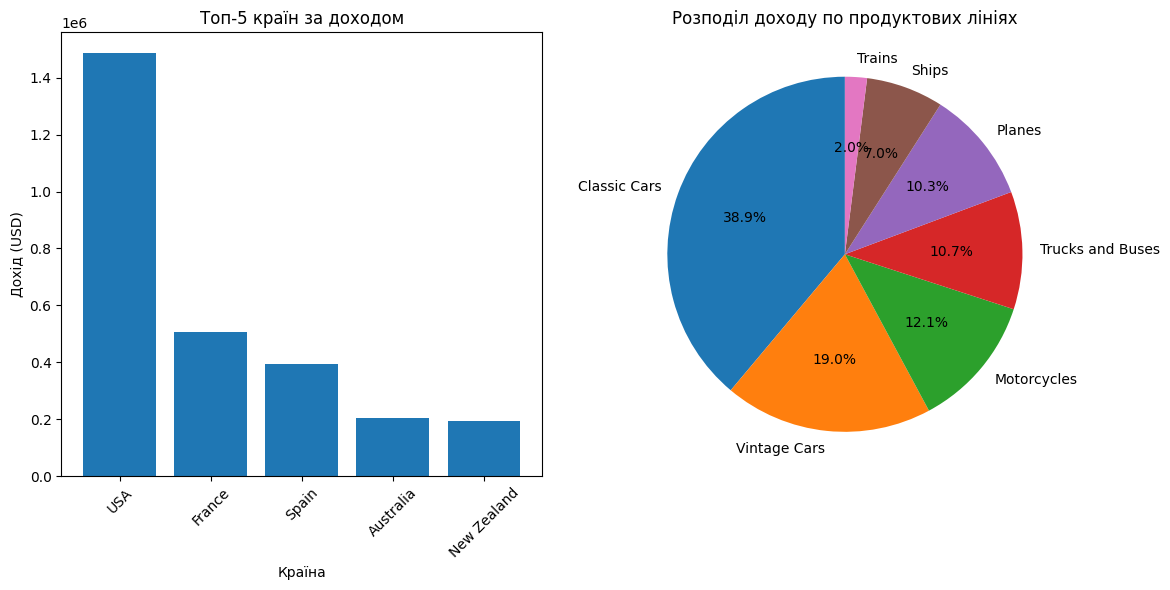

   ✅ Візуалізація збережена: reports/ClassicModels_Simple_Charts_20250723_132513.png

🎉 ETL пайплайн завершено успішно!
📁 Створені файли:
   📊 reports/ClassicModels_Simple_Report_20250723_132513.xlsx
   🔗 reports/ClassicModels_Simple_API_20250723_132513.json
   📈 reports/ClassicModels_Simple_Charts_20250723_132513.png

📈 ОСНОВНІ ПОКАЗНИКИ:
   💰 Загальний дохід: $4,344,182.02
   💵 Загальний прибуток: $1,739,574.51
   📊 Маржа прибутку: 40.04%
   🛒 Кількість замовлень: 147
   🏆 Топ країна: USA

✅ Результати виконання:
📋 Топ-5 країн за доходом:


,country,Orders_Count,Total_Revenue,Total_Profit,Items_Sold,Profit_Margin_%
0,USA,52,1485054.44,597654.15,16265,40.24
1,France,19,506660.01,211528.15,5632,41.75
2,Spain,13,392816.48,156131.39,4357,39.75
3,Australia,6,204213.18,78176.66,2232,38.28
4,New Zealand,5,195592.89,78147.87,2229,39.95



📦 Продуктові лінії:


,productLine,Orders_Count,Total_Revenue,Total_Profit,Items_Sold,Profit_Margin_%
0,Classic Cars,94,1689307.07,673958.15,15470,39.90
1,Vintage Cars,85,823927.95,337219.36,10487,40.93
2,Motorcycles,37,527243.84,222485.41,5976,42.20
3,Trucks and Buses,40,465390.00,182082.20,5024,39.12
4,Planes,33,445464.30,171794.41,5509,38.57
5,Ships,32,305951.40,121444.93,3935,39.69
6,Trains,20,86897.46,30590.05,1290,35.20


In [ ]:
# === ЗАПУСК ETL ПАЙПЛАЙНУ ===
etl_result = create_etl_report(engine)

if etl_result:
    print("\n✅ Результати виконання:")
    print("📋 Топ-5 країн за доходом:")
    display(etl_result['country_analytics'])

    print("\n📦 Продуктові лінії:")
    display(etl_result['product_analytics'])
else:
    print("\n❌ ETL пайплайн не виконався. Перевірте помилки вище.")